In [4]:
import duckdb
import pandas as pd
import requests
import io

# 1. Connect DuckDB in-memory engine
con = duckdb.connect(database=':memory:')

# 2. ABS API endpoint URL
api_url = "https://data.api.abs.gov.au/rest/data/ABS,CPI,/3...50.M?startPeriod=2026-04"

# 3. Request data with the appropriate Accept header for CSV output
headers = {"Accept": "text/csv"}
response = requests.get(api_url, headers=headers)

# 4. Parse the CSV response into Pandas
if response.status_code == 200:
    df_cpi = pd.read_csv(io.StringIO(response.text))

    # Load DataFrame directly into DuckDB
    con.register('abs_cpi_monthly', df_cpi)

    print("Columns returned:", df_cpi.columns.tolist())
    con.sql("SELECT * FROM abs_cpi_monthly LIMIT 5").show()
else:
    print(f"Failed to fetch data. HTTP Status Code: {response.status_code}")

Columns returned: ['DATAFLOW', 'MEASURE', 'INDEX', 'TSEST', 'REGION', 'FREQ', 'TIME_PERIOD', 'OBS_VALUE', 'UNIT_MEASURE', 'OBS_STATUS', 'DECIMALS', 'OBS_COMMENT', 'BASE_PERIOD']
┌────────────────┬─────────┬────────┬───────┬────────┬─────────┬─────────────┬───────────┬──────────────┬────────────┬──────────┬─────────────┬─────────────┐
│    DATAFLOW    │ MEASURE │ INDEX  │ TSEST │ REGION │  FREQ   │ TIME_PERIOD │ OBS_VALUE │ UNIT_MEASURE │ OBS_STATUS │ DECIMALS │ OBS_COMMENT │ BASE_PERIOD │
│    varchar     │  int64  │ int64  │ int64 │ int64  │ varchar │   varchar   │  double   │   varchar    │  varchar   │  double  │   double    │    int64    │
├────────────────┼─────────┼────────┼───────┼────────┼─────────┼─────────────┼───────────┼──────────────┼────────────┼──────────┼─────────────┼─────────────┤
│ ABS:CPI(2.0.0) │       3 │  40077 │    10 │     50 │ M       │ 2026-04     │      12.4 │ PCT          │ NULL       │     NULL │        NULL │          25 │
│ ABS:CPI(2.0.0) │       3 │  40

In [5]:
# SQL Query: Calculate month-over-month inflation change using LAG()
sql_query = """
WITH cpi_data AS (
    SELECT
        TIME_PERIOD AS period,
        OBS_VALUE AS cpi_index,
        -- Pull the CPI value from the previous available record
        LAG(OBS_VALUE) OVER (ORDER BY TIME_PERIOD) AS prev_cpi_index
    FROM abs_cpi_monthly
)
SELECT
    period,
    cpi_index,
    prev_cpi_index,
    ROUND(cpi_index - prev_cpi_index, 2) AS index_point_change,
    ROUND(
        ((cpi_index - prev_cpi_index) / prev_cpi_index) * 100,
        2
    ) AS mom_inflation_rate_pct
FROM cpi_data
ORDER BY period DESC;
"""

# Execute and render output in DuckDB
con.sql(sql_query).show()

┌─────────┬───────────┬────────────────┬────────────────────┬────────────────────────┐
│ period  │ cpi_index │ prev_cpi_index │ index_point_change │ mom_inflation_rate_pct │
│ varchar │  double   │     double     │       double       │         double         │
├─────────┼───────────┼────────────────┼────────────────────┼────────────────────────┤
│ 2026-07 │       6.1 │            3.6 │                2.5 │                  69.44 │
│ 2026-07 │       5.7 │            6.6 │               -0.9 │                 -13.64 │
│ 2026-07 │       1.7 │           -4.1 │                5.8 │                -141.46 │
│ 2026-07 │      -4.1 │            3.1 │               -7.2 │                -232.26 │
│ 2026-07 │       4.8 │            3.8 │                1.0 │                  26.32 │
│ 2026-07 │       3.8 │            6.0 │               -2.2 │                 -36.67 │
│ 2026-07 │       6.0 │            4.7 │                1.3 │                  27.66 │
│ 2026-07 │       4.7 │            3.2 │   

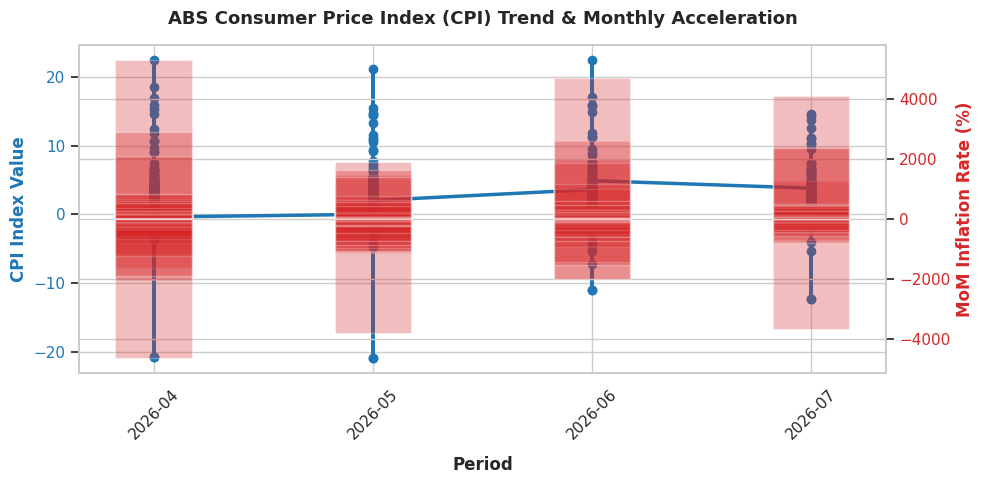

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Convert the DuckDB query result directly into a Pandas DataFrame
df_results = con.sql(sql_query).df()

# 2. Sort periods chronologically for plotting
df_results = df_results.sort_values('period')

# 3. Set visual style
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot CPI Index Value on the primary Y-axis
color_blue = '#1f77b4'
ax1.set_xlabel('Period', fontweight='bold', labelpad=10)
ax1.set_ylabel('CPI Index Value', color=color_blue, fontweight='bold')
ax1.plot(df_results['period'], df_results['cpi_index'], color=color_blue, marker='o', linewidth=2.5, label='CPI Index')
ax1.tick_params(axis='y', labelcolor=color_blue)
plt.xticks(rotation=45)

# Plot MoM Inflation % on a secondary Y-axis
ax2 = ax1.twinx()
color_red = '#d62728'
ax2.set_ylabel('MoM Inflation Rate (%)', color=color_red, fontweight='bold')
ax2.bar(df_results['period'], df_results['mom_inflation_rate_pct'], color=color_red, alpha=0.3, width=0.35, label='MoM Inflation %')
ax2.tick_params(axis='y', labelcolor=color_red)

# Title and Layout
plt.title('ABS Consumer Price Index (CPI) Trend & Monthly Acceleration', fontsize=13, fontweight='bold', pad=15)
fig.tight_layout()

# Render chart
plt.show()